---
# Import Library

---

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as py

---
# Data Loading

---

In [21]:
# Since the data is located on directory '../data/cleaned' from DE part:
df = pd.read_csv('../data/cleaned/modelling_df_v0_1.csv', index_col=0) # use index column
backup_df = df.copy() # for backup of changes in original df

# Check the summary with info method()
df.info()

pd.set_option('display.max_columns', None) # to see all columns
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 117784 entries, 0 to 118433
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117784 non-null  object 
 1   customer_id                    117784 non-null  object 
 2   order_status                   117784 non-null  object 
 3   order_purchase_timestamp       117784 non-null  object 
 4   order_approved_at              117608 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  117784 non-null  object 
 8   order_item_id                  117597 non-null  float64
 9   product_id                     117597 non-null  object 
 10  shipping_limit_date            117597 non-null  object 
 11  price                          117597 non-null  float64
 12  freight_value                  1175

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,29.0,178.0,1.0,400.0,19.0,13.0,19.0,0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,46.0,232.0,1.0,420.0,24.0,19.0,21.0,0
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-23 19:45:59,45.00,27.20,1.0,credit_card,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59.0,468.0,3.0,450.0,30.0,10.0,20.0,0
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-19 20:31:37,19.90,8.72,1.0,credit_card,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,38.0,316.0,4.0,250.0,51.0,15.0,15.0,0
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,060cb19345d90064d1015407193c233d,2017-07-13 22:10:13,147.90,27.36,1.0,credit_card,6.0,175.26,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,0
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,a1804276d9941ac0733cfd409f5206eb,2017-04-19 13:25:17,49.90,16.05,1.0,credit_card,1.0,65.95,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,NaN,NaN,NaN,600.0,35.0,35.0,15.0,0
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,4520766ec412348b8d4caa5e8a18c464,2017-05-22 13:22:11,59.99,15.17

#TODO hasil bahasan sama bang kevin, jadinya 2 df di bagian EDA ini, kedua2nya dilakuin

In [18]:
# Aggregated data also located in same directory '../data/cleaned' from DE part:
df_agg = pd.read_csv('../data/cleaned/order_agg_modeling_v0_1.csv', index_col=0) # use index column
backup_df_agg = df_agg.copy() # for backup of changes in original df_agg

# Check the summary with info method()
df_agg.info()

df_agg.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,29.99,voucher,38.71,1.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,118.70,boleto,141.46,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,147.90,27.36,147.90,credit_card,175.26,6.0,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,49.90,16.05,49.90,credit_card,65.95,1.0,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,59.99,15.17,59.99,credit_card,75.16,3.0,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1.0,19.90,16.05,19.90,boleto,35.95,1.0,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1.0,149.99,19.77,149.99,credit_card,169.76,1.0,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,0


In [4]:
df.customer_id.value_counts()

customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
63b964e79dee32a3587651701a2b8dbf    24
                                    ..
741a12b94b48a426f2cbd87b83a62c29     1
7fb28b72559f15550a82e040b117dcc6     1
d75f7a65c23672520fa4dc4125443ff9     1
6a2896a95ecb9df4c195ac3ba4139cf7     1
edb027a75a1449115f6b43211ae02a24     1
Name: count, Length: 98832, dtype: int64

Note that there are some customers with multiple orders on the dataset. Perhaps there may be multiple cancelled order for each customer that later we will observed.

In [ ]:
df1 = df.copy() #TODO cell code ini nanti hapus, krn ku define backup_df di atas, biar seragam aja ama yang dibuat bang evan
# ke bawah-bawah pakai df semua aja, justru yang backup_df yang ga disentuh

In [6]:
df.order_approved_at.isna() #TODO karena jadinya pakai order_purchase_timestamp, gaperlu cek isna, krn ga ada missing kan dari .info di atas, jadi cell code ini mungkin tidak perlu

0         False
1         False
2         False
3         False
4         False
          ...  
118429    False
118430    False
118431    False
118432    False
118433    False
Name: order_approved_at, Length: 117784, dtype: bool

#TODO kalau ini ke bawah aslinya nomor 4, nanti pindah ke bawah aja bang

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(df["order_purchase_timestamp"]) #TODO pakainya order_purchase_timestamp soalnya di DS nanti

In [ ]:
cancel_date = df.set_index("order_purchase_timestamp")["is_canceled"].resample("W").sum()

In [9]:
cancel_date

order_purchase_timestamp
2016-09-04    0
2016-09-11    1
2016-09-18    1
2016-09-25    0
2016-10-02    1
             ..
2018-09-23    2
2018-09-30    3
2018-10-07    2
2018-10-14    0
2018-10-21    2
Freq: W-SUN, Name: is_canceled, Length: 112, dtype: int64

In [10]:
cancel_date.info() #TODO ini ku geser ke bawah, kalau bisa hindari ada cek di atas cell code nya (definisi di bawah, tapi .info di atasnya), takutnya lupa dihapus aja

<class 'pandas.core.series.Series'>
DatetimeIndex: 112 entries, 2016-09-04 to 2018-10-21
Freq: W-SUN
Series name: is_canceled
Non-Null Count  Dtype
--------------  -----
112 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


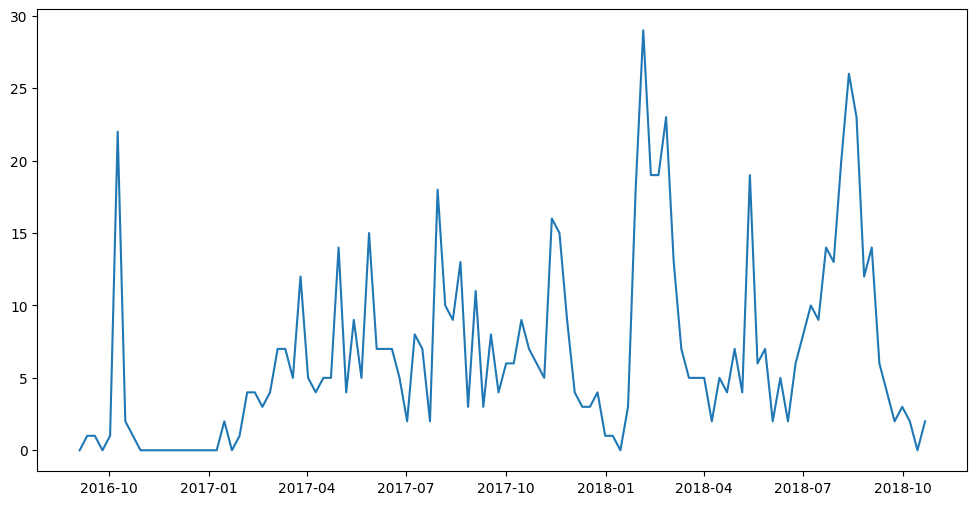

In [11]:
plt.figure(figsize=(12,6))
plt.plot(cancel_date.index, cancel_date.values)
plt.show()

#TODO sebelum EDA perlu ada section Data Cleaning, terutama kolom yang mau dianalisa di EDA aja bang malik, contohnya fokus kolom `product_id` (EDA no.3), 

hmm nomor 8 dan 9 itu perlu semuanya ga ada missing values sih ._. nanti kalau mau bahas missing values discord aja kalau butuh gpp

---
# Exploratory Data Analysis

---

All of the questions:
#TODO ini nanti crosscheck di discord lagi, siapa tau ada yang diedit, terutama nomor 3 itu baru dari bahasan ama bang kevin -- harapannya hasil dari nomor 3 ga bagus, maka nomor 4 dst cukup `df` aja, gaperlu 

1. What is the overall cancellation rate in the historical dataset?
2. What is the distribution of customer level cancellation rate? #TODO sepertinya malah jadi banyak cancellation paling tinggi dari setiap customer
3. How is the cancellation rate for each product? #TODO ini yang baru -- jadi per `product_id` bang
4. Which customer segments are most likely to cancel their orders based on customer behaviour and transaction history
5. When do order cancellations most frequently occur?
6. Where do order cancellation most frequently occur, based on customer location?
7. How is the cancellation rate by payment method, shipping option and city?
8. Which features show the strongest relationship with order cancellations?
9. For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?

---
## 1. Overall cancellation rate

---

In [12]:
cancel_rate = df.is_canceled.value_counts()
cancel_rate

is_canceled
0    117039
1       745
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

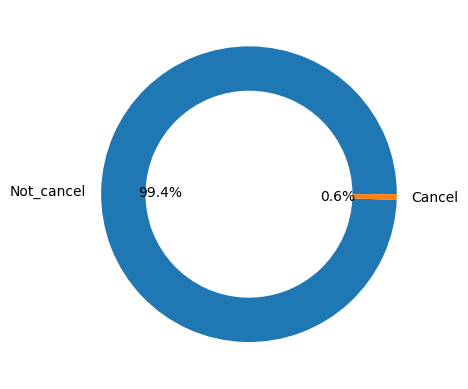

In [13]:
plt.pie(
    cancel_rate.values,
    labels= ["Not_cancel","Cancel"],
    autopct="%1.1f%%",
    explode=[0,0],
    wedgeprops={'width':0.3}
)
plt.show


---
## nomor 2

---

In [ ]:
rate_cancel_percustomer= df.groupby("customer_id")["is_canceled"].sum()
top_5 = rate_cancel_percustomer.sort_values(ascending=False).head(5)

In [15]:
rate_cancel_percustomer.sort_values(ascending=False)

customer_id
33b3ac58c257992bb9f0dff11643b8d0    9
20153d17ff713721abd8b4c082d5e4d5    8
c52f8523a6448c43354e5ca966f61e4c    6
616833eaef04d25b67207119cd6936dc    6
e91409937a0fd26a57310548858d1762    6
                                   ..
55cae1e7c9b2dd0420cf1f95699d77a6    0
55ca353ee53173476849d5e2325d42f5    0
55ca0a4d904df9708853ea6231f68a26    0
55ca07ff32dc30f00ded4c99f8ea9124    0
ffffa3172527f765de70084a7e53aae8    0
Name: is_canceled, Length: 98832, dtype: int64

<Axes: xlabel='is_canceled', ylabel='customer_id'>

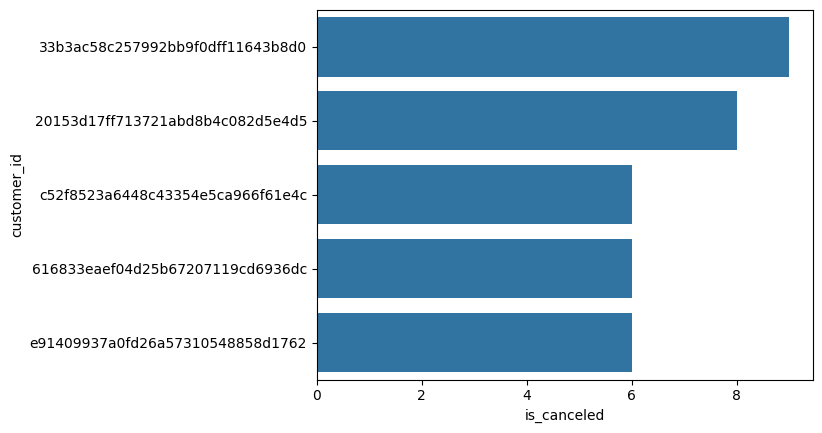

In [16]:
sns.barplot(top_5,orient='h')

In [17]:
top_5

customer_id
33b3ac58c257992bb9f0dff11643b8d0    9
20153d17ff713721abd8b4c082d5e4d5    8
c52f8523a6448c43354e5ca966f61e4c    6
616833eaef04d25b67207119cd6936dc    6
e91409937a0fd26a57310548858d1762    6
Name: is_canceled, dtype: int64

# nomor 3